# Multiple Linear Regression (tanpa sklearn)
Dataset: harga rumah dari **luas tanah** dan **luas bangunan**.

Model:
\[
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2
\]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
# Baca data dari CSV
# Pastikan file harga_rumah_mlr.csv ada di folder kerja yang sama dengan notebook ini.
df = pd.read_csv('/PyAi/harga_rumah_mlr.csv')

print(df.head())
print("\nJumlah baris:", len(df))


    id  luas_tanah_m2  luas_bangunan_m2  harga_juta
0  H01             60                45         455
1  H02             70                50         520
2  H03             80                55         590
3  H04             90                65         690
4  H05            100                70         760

Jumlah baris: 20


In [7]:
# Ambil variabel (2 fitur + 1 target)
X = df[["luas_tanah_m2", "luas_bangunan_m2"]].to_numpy(dtype=float)
y = df[["harga_juta"]].to_numpy(dtype=float)  # bentuk (n,1)

n = X.shape[0]
print("Shape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (20, 2)
Shape y: (20, 1)


In [8]:
# Tambahkan kolom 1 untuk intercept (bias)
X_b = np.c_[np.ones((n, 1)), X]  # (n, 3)
print("Shape X_b:", X_b.shape)


Shape X_b: (20, 3)


In [9]:
# Hitung koefisien beta pakai Normal Equation:
# beta = (X^T X)^(-1) X^T y
beta = np.linalg.inv(X_b.T @ X_b) @ (X_b.T @ y)

b0, b1, b2 = beta.flatten()
print("Intercept (b0):", b0)
print("Koef luas_tanah (b1):", b1)
print("Koef luas_bangunan (b2):", b2)

print(f"\nPersamaan: Ŷ = {b0:.6f} + {b1:.6f}*(luas_tanah) + {b2:.6f}*(luas_bangunan)")


Intercept (b0): -84.26735478984892
Koef luas_tanah (b1): 3.238873813529409
Koef luas_bangunan (b2): 7.486346305776699

Persamaan: Ŷ = -84.267355 + 3.238874*(luas_tanah) + 7.486346*(luas_bangunan)


In [10]:
# Prediksi
y_pred = X_b @ beta  # (n,1)
residual = y - y_pred


In [11]:
# Fungsi evaluasi
def mae(y_true, y_hat):
    return float(np.mean(np.abs(y_true - y_hat)))

def mse(y_true, y_hat):
    return float(np.mean((y_true - y_hat) ** 2))

def rmse(y_true, y_hat):
    return float(np.sqrt(mse(y_true, y_hat)))

def r2_score(y_true, y_hat):
    y_true = np.asarray(y_true)
    y_hat = np.asarray(y_hat)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)
    sse = np.sum((y_true - y_hat) ** 2)
    return float(1 - (sse / sst))


In [12]:
# Hitung metrik
mae_val = mae(y, y_pred)
mse_val = mse(y, y_pred)
rmse_val = rmse(y, y_pred)
r2_val = r2_score(y, y_pred)

print("MAE:", mae_val)
print("MSE:", mse_val)
print("RMSE:", rmse_val)
print("R-squared:", r2_val)


MAE: 6.457546456897802
MSE: 65.25372113259793
RMSE: 8.077977539743344
R-squared: 0.9990074007760451


In [13]:
# Lihat hasil prediksi + residu dalam tabel
out = df.copy()
out["pred_harga_juta"] = y_pred.flatten()
out["residu"] = (y - y_pred).flatten()

print(out.head(10))


    id  luas_tanah_m2  luas_bangunan_m2  harga_juta  pred_harga_juta  \
0  H01             60                45         455       446.950658   
1  H02             70                50         520       516.771127   
2  H03             80                55         590       586.591597   
3  H04             90                65         690       693.843798   
4  H05            100                70         760       763.664268   
5  H06            110                80         860       870.916469   
6  H07            120                85         935       940.736939   
7  H08            130                95        1030      1047.989140   
8  H09            140               100        1110      1117.809610   
9  H10            150               110        1215      1225.061811   

      residu  
0   8.049342  
1   3.228873  
2   3.408403  
3  -3.843798  
4  -3.664268  
5 -10.916469  
6  -5.736939  
7 -17.989140  
8  -7.809610  
9 -10.061811  


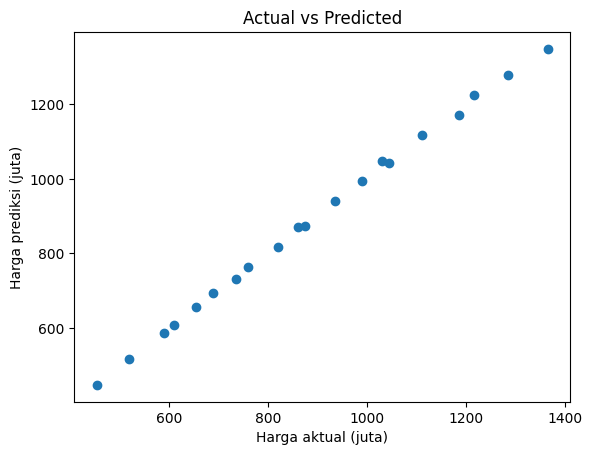

In [14]:
# Plot: Actual vs Predicted
plt.scatter(out["harga_juta"], out["pred_harga_juta"])
plt.title("Actual vs Predicted")
plt.xlabel("Harga aktual (juta)")
plt.ylabel("Harga prediksi (juta)")
plt.show()


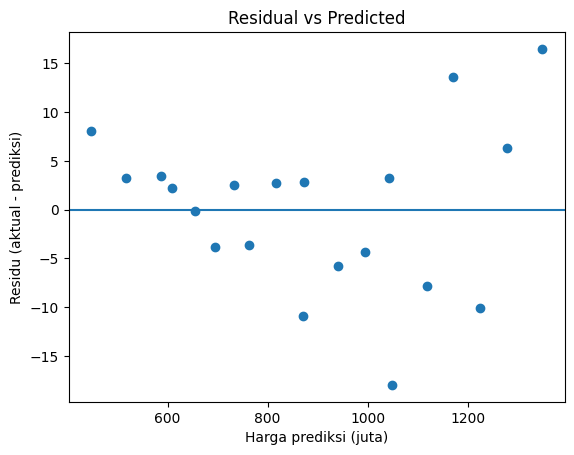

In [15]:
# Plot: Residuals vs Predicted
plt.scatter(out["pred_harga_juta"], out["residu"])
plt.axhline(0)
plt.title("Residual vs Predicted")
plt.xlabel("Harga prediksi (juta)")
plt.ylabel("Residu (aktual - prediksi)")
plt.show()
